<div style="background:#FFF5F8;border:3px solid #E0218A;border-radius:16px;padding:28px;text-align:center;">
<h1 style="color:#E0218A;margin:0;">🐥 Curso de Machine Learning · Clase 3 de 7</h1>
<h2 style="color:#1B2A5B;margin:10px 0 4px;">El 70% del trabajo real, limpiar las solicitudes de crédito</h2>
<p style="color:#1B2A5B;margin:6px 0;">Con la Miss Yera · <a href="https://missyera.com">missyera.com</a> · @soymissyera</p>
<p style="color:#E0218A;margin:0;"><b>Regla de oro del curso, nadie ejecuta una celda sin predecir en voz alta qué va a pasar.</b></p>
</div>

## 🧭 ¿Dónde estamos en el curso?

Progreso, 🐥🐥🐥▫️▫️▫️▫️ · clase 3 de 7

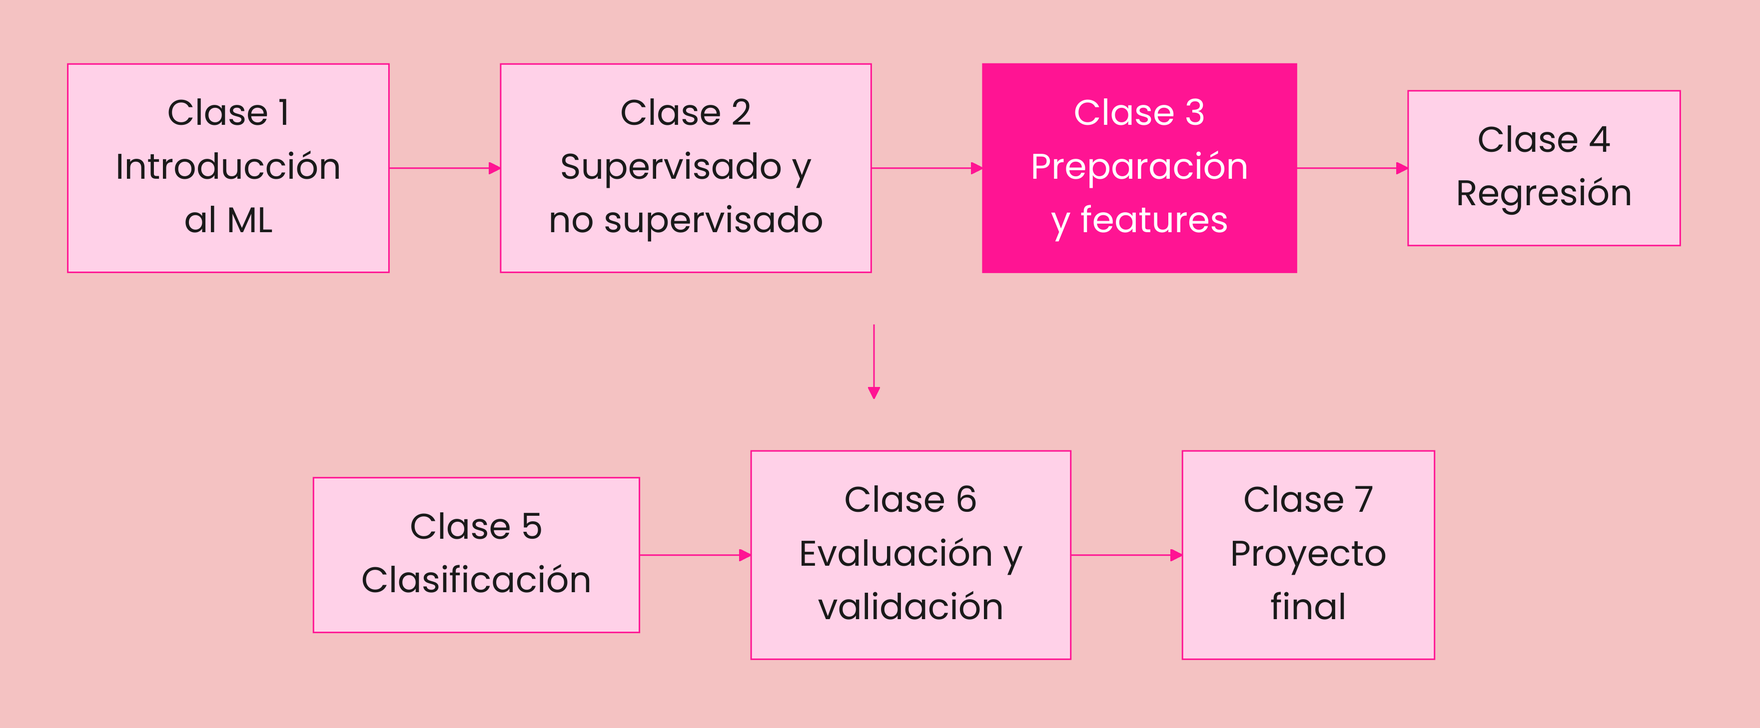


## 🔁 Antes de arrancar, 60 segundos de la clase anterior

En la clase 2, supervisado o no supervisado, el mapa que evita el 80% de los errores, dejamos lista la base para lo de hoy. Si algo de lo que sigue no te suena, regresa a ese notebook o al video de la clase 2 de la playlist antes de continuar.


In [ ]:
#@title 🎬 Toca play · Quiz de entrada, ¿qué te llevaste de la clase anterior?
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de entrada, ¿qué te llevaste de la clase anterior?</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. ¿Con qué pregunta sabes si tu problema es supervisado?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin3_0" value="0"> ¿Tengo muchos datos?</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin3_0" value="1"> ¿Tengo la respuesta correcta en mis datos?</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin3_0" value="2"> ¿Tengo una computadora potente?</label><div id="qin3_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. Predecir el monto de la cuota mensual es...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin3_1" value="0"> Clasificación, es una categoría</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin3_1" value="1"> Regresión, es un número continuo</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin3_1" value="2"> Clustering, son grupos</label><div id="qin3_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "el mapa de decisi\u00f3n arranca con la respuesta correcta"], [1, "cuota en soles es un n\u00famero, no una categor\u00eda"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qin3_"+i+"\']:checked");
        var fb=document.getElementById("qin3_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🎯 Lo que vas a lograr hoy

- Auditar un dataset como detective antes de tocar una sola fila.
- Limpiar con criterio, cada decisión de limpieza con su porqué dicho en voz alta.
- Partir en train y test y escalar sin caer en la trampa del data leakage.


## 📩 El pedido de la semana en PolliCreditos

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><i>"Las solicitudes llegan sucias del formulario web, duplicadas, con edades imposibles y celdas vacías. Necesito que las dejes listas para el modelo, y explícame cada decisión."</i><br><b style="color:#1B2A5B;">El CEO de PolliCreditos 🐥</b></div>



<div style="background: linear-gradient(135deg, #FF1493 0%, #FF69B4 55%, #FFB6C1 100%); border-radius: 22px; padding: 42px 36px; text-align: center; color: white; font-family: 'Inter', sans-serif;">
  <div style="font-size: 15px; letter-spacing: 3px; opacity: .95;">🐤 CURSO DE MACHINE LEARNING · CLASE 03</div>
  <h1 style="margin: 14px 0 6px 0; font-size: 40px; color: white;">Preparación de datos y feature engineering</h1>
  <div style="font-size: 18px; opacity: .96;">El ochenta por ciento del trabajo que define el éxito del modelo</div>
  <div style="margin-top: 22px; font-size: 14px; background: rgba(255,255,255,.18); display: inline-block; padding: 8px 20px; border-radius: 999px;">Miss Yera · missyera.com · @soymissyera</div>
</div>



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 17px;">🎯 Al final de esta clase vas a poder</b>
<ul style="margin-top: 10px;"><li>Auditar la calidad de un dataset antes de modelar</li>
<li>Tratar nulos, duplicados y valores imposibles con criterio</li>
<li>Codificar variables categóricas con get_dummies</li>
<li>Escalar variables numéricas y saber cuándo hace falta</li>
<li>Crear features nuevas que multiplican el poder del modelo</li>
<li>Partir en train y test sin cometer data leakage</li></ul>
</div>


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta oficial Miss Yera para todos los gráficos de la clase
YERA = ['#FF1493', '#FF69B4', '#FFB6C1', '#00C9A7', '#FFC75F', '#1B2A5B']
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.prop_cycle': plt.cycler(color=['#FF1493', '#00C9A7', '#1B2A5B', '#FFC75F', '#FF69B4']),
})
np.random.seed(42)  # semilla fija, reproducible o no existe
print('Setup listo, pollito 🐥')

## 1. La misión de hoy

Una fintech nos entrega la data cruda de sus solicitudes de préstamo. Quiere predecir impagos, pero la data llega como llega siempre en la vida real, sucia. Hoy no entrenamos ningún modelo, hoy preparamos el terreno, que es donde se gana o se pierde el proyecto.

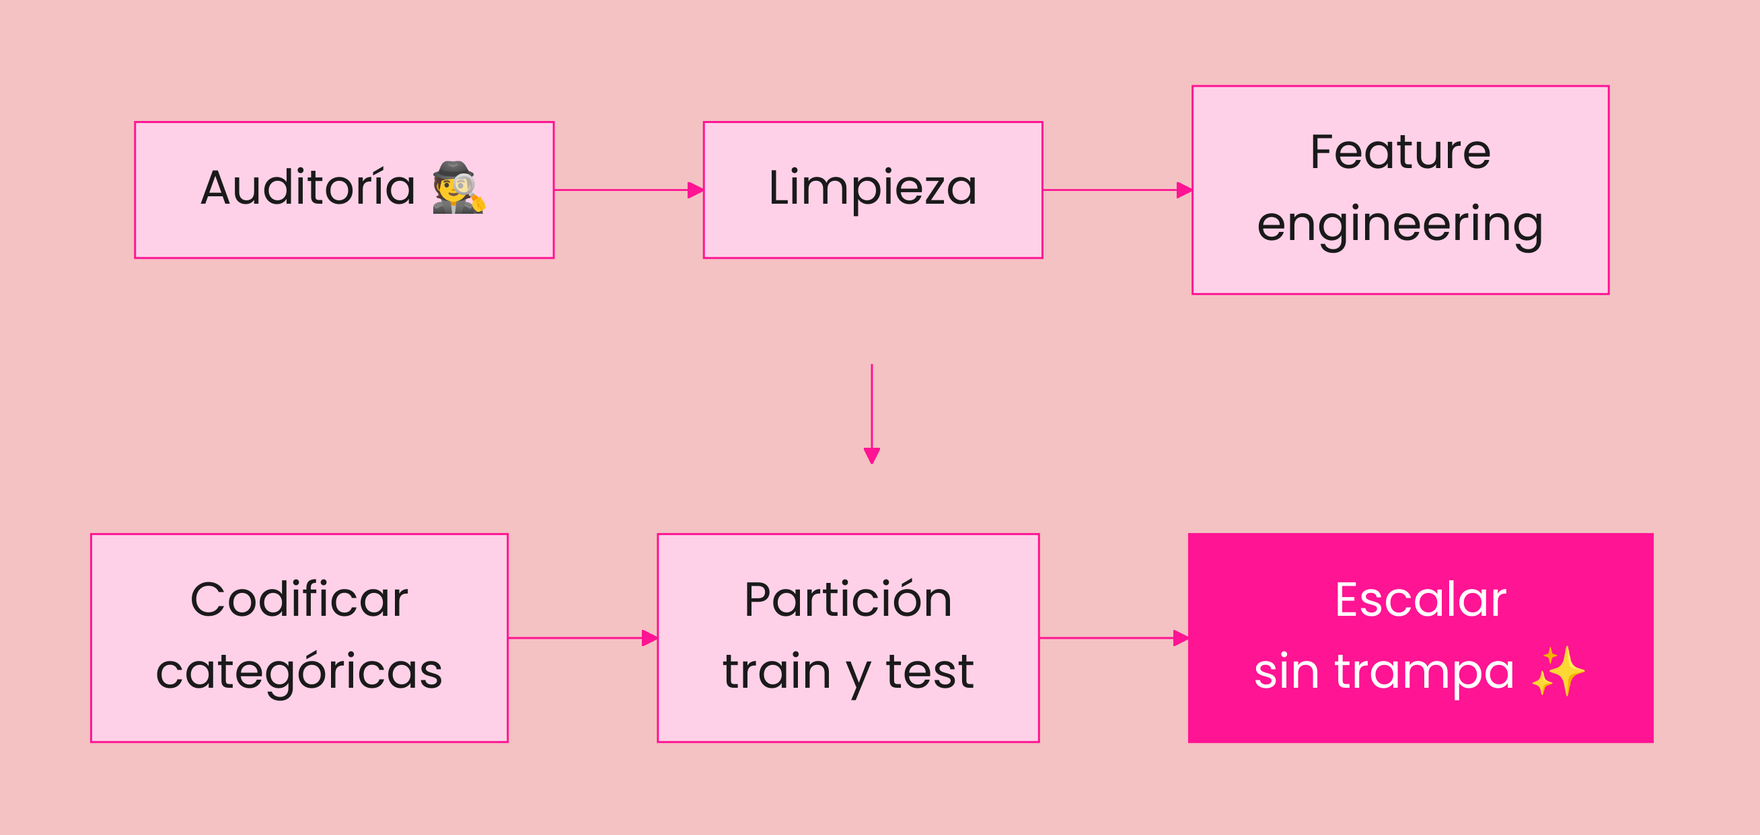

*La preparación es una cadena con orden, auditar, limpiar, crear features, codificar, partir y recién escalar.*


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

df = pd.DataFrame({
    "cliente_id": np.arange(1000, 1000 + n),
    "edad": np.random.randint(18, 70, n).astype(float),
    "ingreso_mensual": np.round(np.random.lognormal(8.1, 0.5, n), 0),
    "distrito": np.random.choice(["miraflores", "Miraflores", "surco", "callao", "SURCO", "comas"], n),
    "monto_prestamo": np.round(np.random.uniform(1000, 20000, n), 0),
    "meses_empleo": np.random.randint(0, 240, n).astype(float),
})

# Las trampas de la vida real, plantadas a propósito
df.loc[np.random.choice(n, 18, replace=False), "ingreso_mensual"] = np.nan
df.loc[np.random.choice(n, 10, replace=False), "meses_empleo"] = np.nan
df.loc[[7, 42, 99], "edad"] = [-5, 150, 200]                      # edades imposibles
df = pd.concat([df, df.iloc[[3, 15, 27]]], ignore_index=True)     # duplicados

# El target, construido con lógica real más ruido
ratio = df["monto_prestamo"] / df["ingreso_mensual"].fillna(df["ingreso_mensual"].median())
prob = 1 / (1 + np.exp(-(ratio * 1.5 - 3 + np.random.normal(0, 0.9, len(df)))))
df["impago"] = (prob > 0.5).astype(int)

print(f"Dataset recibido, {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

## 2. Auditoría, el interrogatorio inicial

In [ ]:
print("Nulos por columna,")
print(df.isna().sum(), "\n")
print(f"Duplicados exactos, {df.duplicated().sum()}")
print(f"Duplicados por cliente_id, {df.duplicated(subset='cliente_id').sum()}\n")
print("Rango de edad,", df["edad"].min(), "a", df["edad"].max(), "← 🚨 hay edades imposibles")
print("Distritos crudos,", sorted(df["distrito"].unique()), "← 🚨 mayúsculas inconsistentes")
print(f"\nBalance del target, {df['impago'].mean():.1%} de impagos")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués de la auditoría</b><br>
Cada problema no detectado aquí se convierte en un modelo mentiroso después. Los duplicados inflan la confianza, los valores imposibles distorsionan los promedios y las categorías inconsistentes parten un grupo en varios. Auditar primero es lo que separa a una profesional de alguien que solo corre fit.
</div>


## 3. Limpieza con criterio, cada decisión tiene su porqué

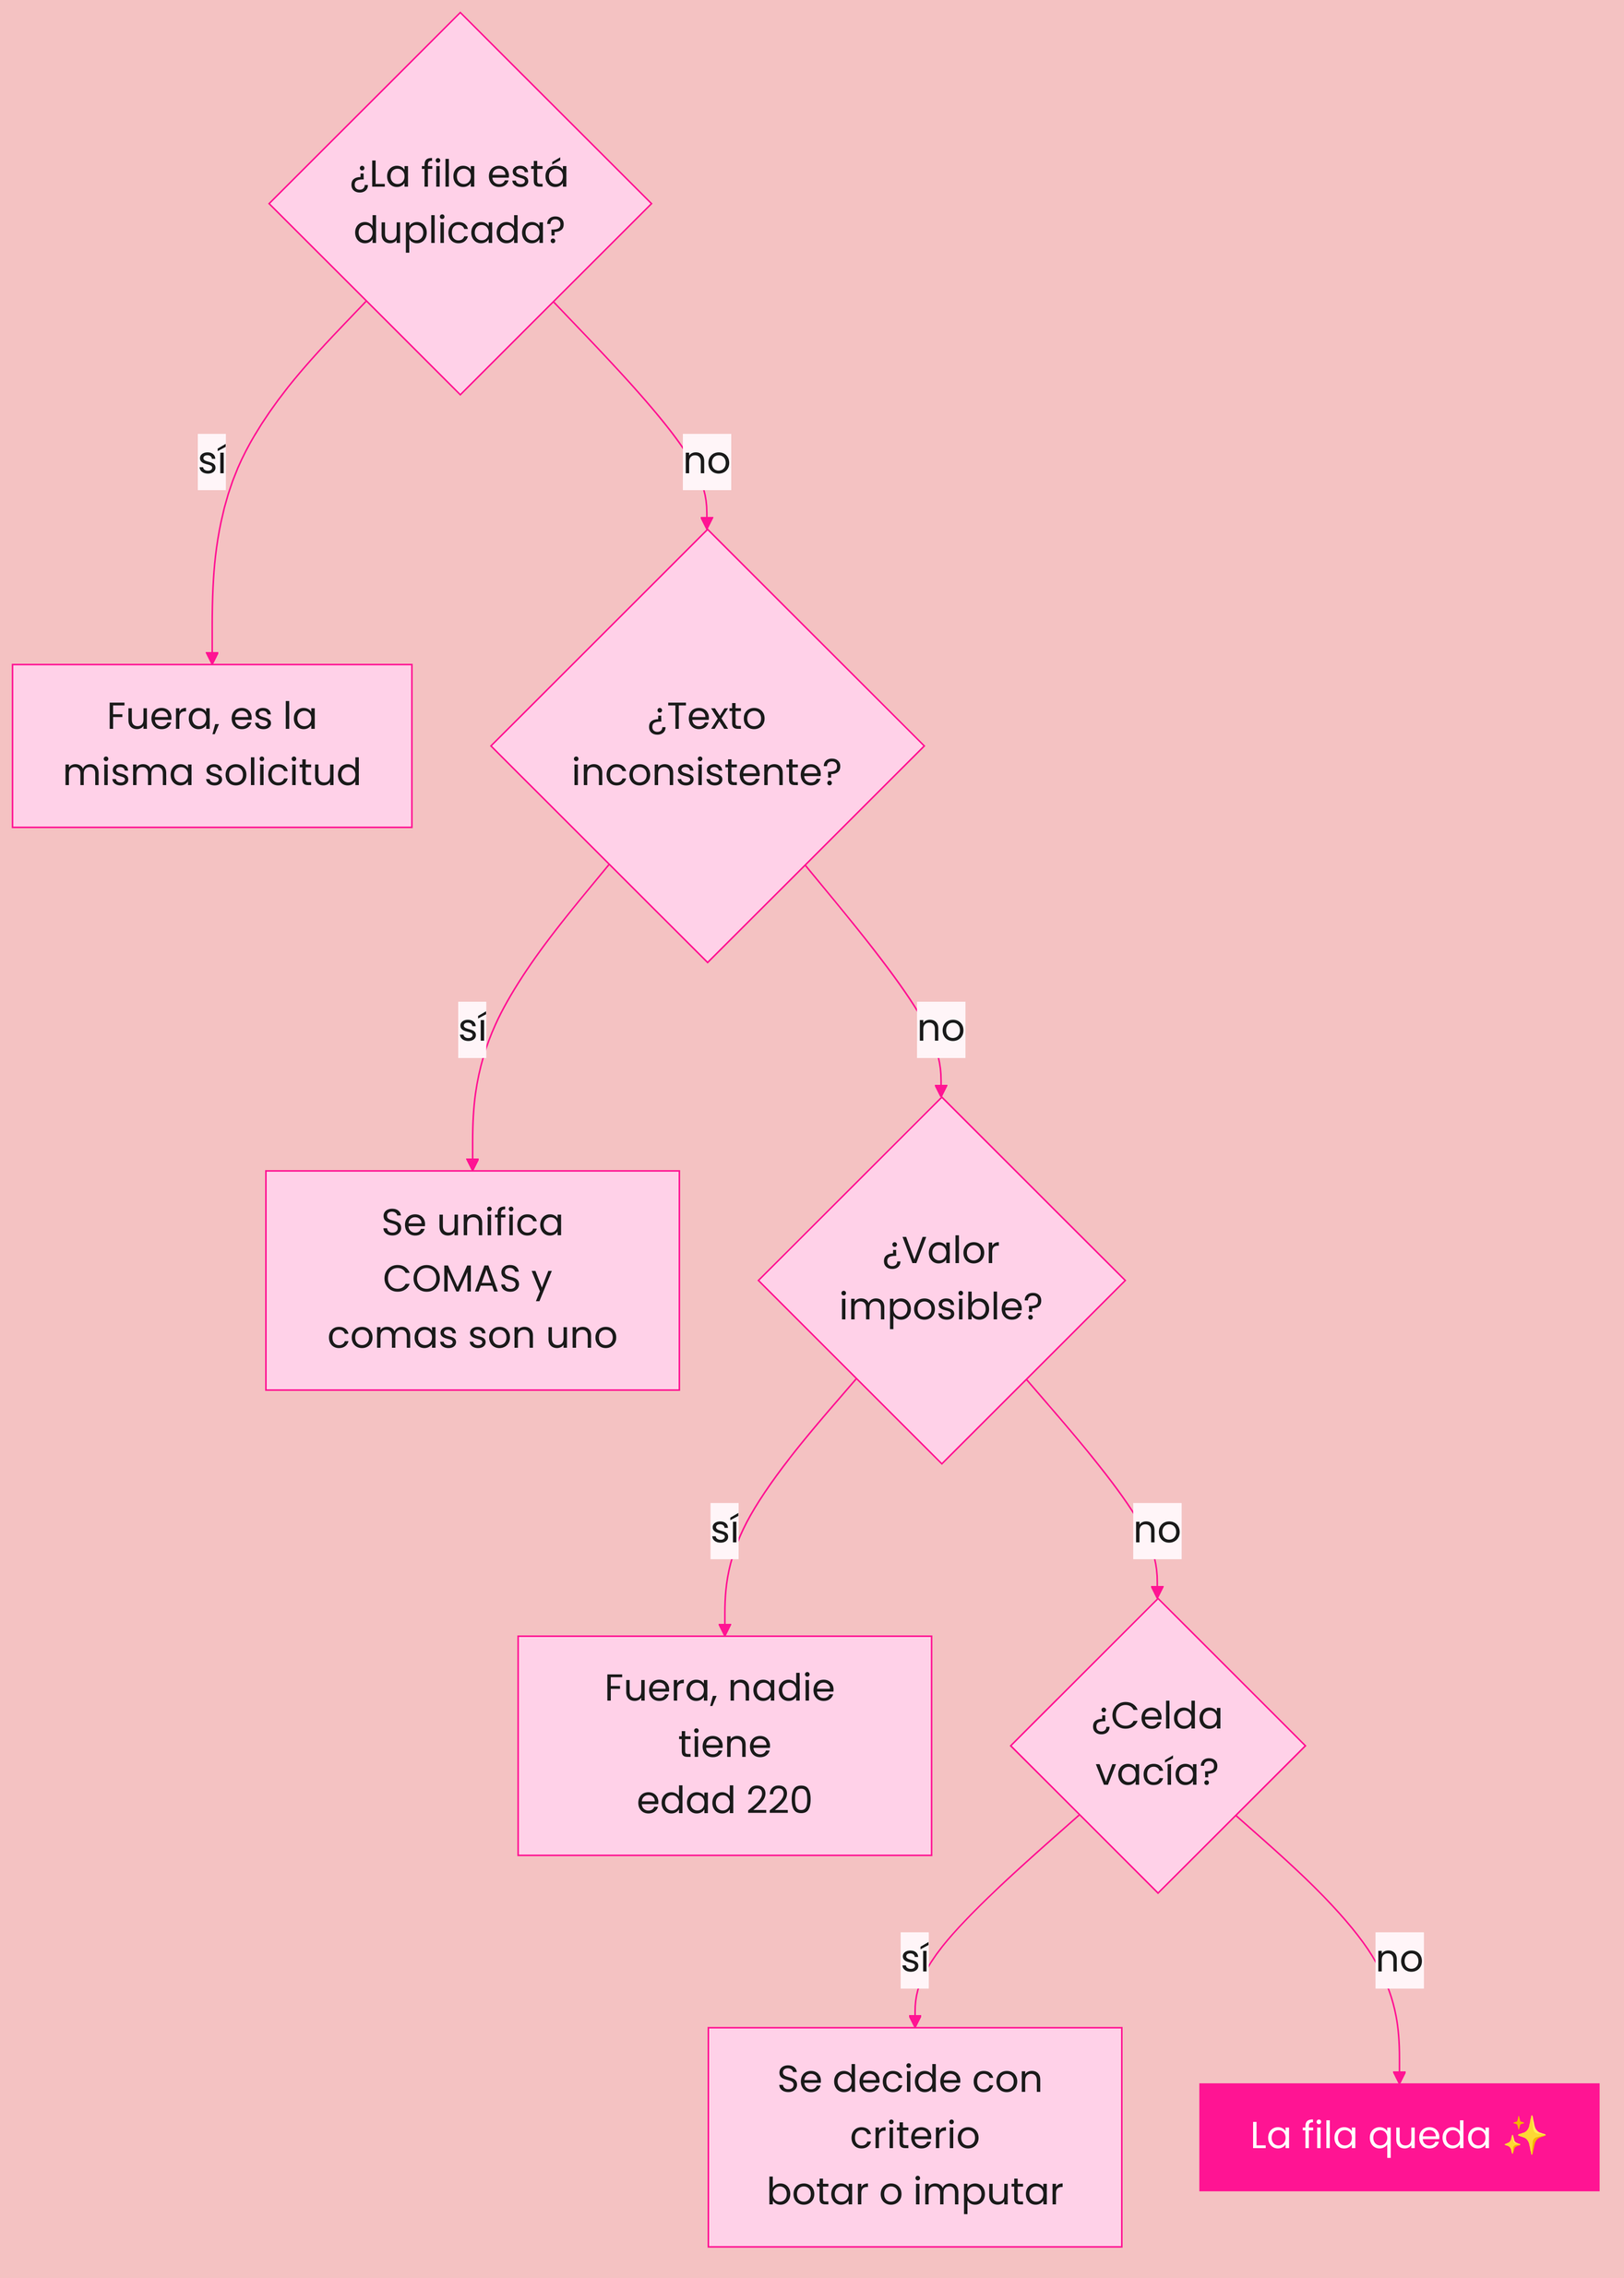

*Cada fila pasa por el mismo interrogatorio, y cada decisión de limpieza tiene su porqué.*


In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
# Decisión 1, fuera duplicados, un cliente cuenta una sola vez
df = df.____(subset="cliente_id").reset_index(drop=True)

# Decisión 2, edades imposibles a nulo y luego se imputan, no se inventan
df.loc[(df["edad"] < 18) | (df["edad"] > 100), "edad"] = np.nan

# Decisión 3, unificar categorías, miraflores y Miraflores son el mismo distrito
df["distrito"] = df["distrito"].str.lower().str.strip()

# Decisión 4, imputar numéricas con la mediana, resistente a valores extremos
for col in ["edad", "ingreso_mensual", "meses_empleo"]:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

print("Nulos restantes,", df.isna().sum().sum())
print("Distritos limpios,", sorted(df["distrito"].unique()))
print(f"Filas finales, {len(df)}")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Por qué la mediana y no el promedio?</b><br>
Porque el ingreso tiene cola larga, pocos clientes ganan muchísimo y jalan el promedio hacia arriba. La mediana es el valor del cliente del medio y no se deja engañar por los extremos. Para variables sesgadas, mediana siempre.
</div>


## 4. Feature engineering, crear señal donde no la había

Aquí es donde el conocimiento del negocio se convierte en poder predictivo. Las features nuevas suelen aportar más que cambiar de modelo.

In [ ]:
# Feature 1, la carga del préstamo sobre el ingreso, el ratio clave del negocio
df["ratio_deuda_ingreso"] = df["monto_prestamo"] / df["ingreso_mensual"]

# Feature 2, estabilidad laboral en años, más interpretable que meses
df["anios_empleo"] = (df["meses_empleo"] / 12).round(1)

# Feature 3, grupos de edad, captura relaciones no lineales
df["grupo_edad"] = pd.cut(df["edad"], bins=[17, 30, 45, 60, 100],
                          labels=["joven", "adulto", "maduro", "senior"])

df[["edad", "grupo_edad", "ingreso_mensual", "monto_prestamo", "ratio_deuda_ingreso", "impago"]].head()

In [ ]:
# ¿Nuestra feature estrella separa a los impagos? Momento de la verdad
fig, ax = plt.subplots()
df[df["impago"] == 0]["ratio_deuda_ingreso"].plot(kind="hist", bins=30, alpha=0.65,
    ax=ax, label="Pagó", color="#00C9A7", edgecolor="white")
df[df["impago"] == 1]["ratio_deuda_ingreso"].plot(kind="hist", bins=30, alpha=0.65,
    ax=ax, label="Impago", color="#C34A36", edgecolor="white")
ax.set_title("El ratio deuda ingreso separa con fuerza a los impagos")
ax.set_xlabel("Ratio préstamo / ingreso mensual")
ax.legend(frameon=False)
plt.show()
print("Una feature que separa las clases así vale oro, la creamos nosotras, no venía en la data")

## 5. Codificar categóricas, los modelos solo comen números

In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
# get_dummies convierte cada categoría en una columna de ceros y unos
df_modelo = pd.____(df, columns=["distrito", "grupo_edad"], drop_first=True, dtype=int)
columnas_nuevas = [c for c in df_modelo.columns if "distrito_" in c or "grupo_" in c]
df_modelo[columnas_nuevas].head()


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Por qué drop_first=True?</b><br>
Si tienes cuatro distritos y creas cuatro columnas, la cuarta es redundante, se deduce de las otras tres. Esa redundancia, llamada multicolinealidad, marea a los modelos lineales. drop_first bota una columna y deja la información intacta.
</div>


## 6. La partición sagrada, train y test

In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
from sklearn.model_selection import train_test_split

features = [c for c in df_modelo.columns if c not in ["cliente_id", "impago", "meses_empleo"]]
X = df_modelo[features]
y = df_modelo["impago"]

X_train, X_test, y_train, y_test = ____(
    X, y, test_size=____, random_state=42, stratify=____
)

print(f"Train, {len(X_train)} filas ({y_train.mean():.1%} impagos)")
print(f"Test,  {len(X_test)} filas ({y_test.mean():.1%} impagos)")
print("Gracias a stratify las proporciones se mantienen gemelas ✅")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués de esta celda</b><br>
El test es el examen sorpresa, datos que el modelo jamás verá durante el entrenamiento. stratify=y mantiene el mismo porcentaje de impagos en ambos lados, crucial cuando las clases están desbalanceadas. random_state fija la partición para que el experimento sea reproducible.
</div>


## 7. Escalar sin hacer trampa, el data leakage al descubierto

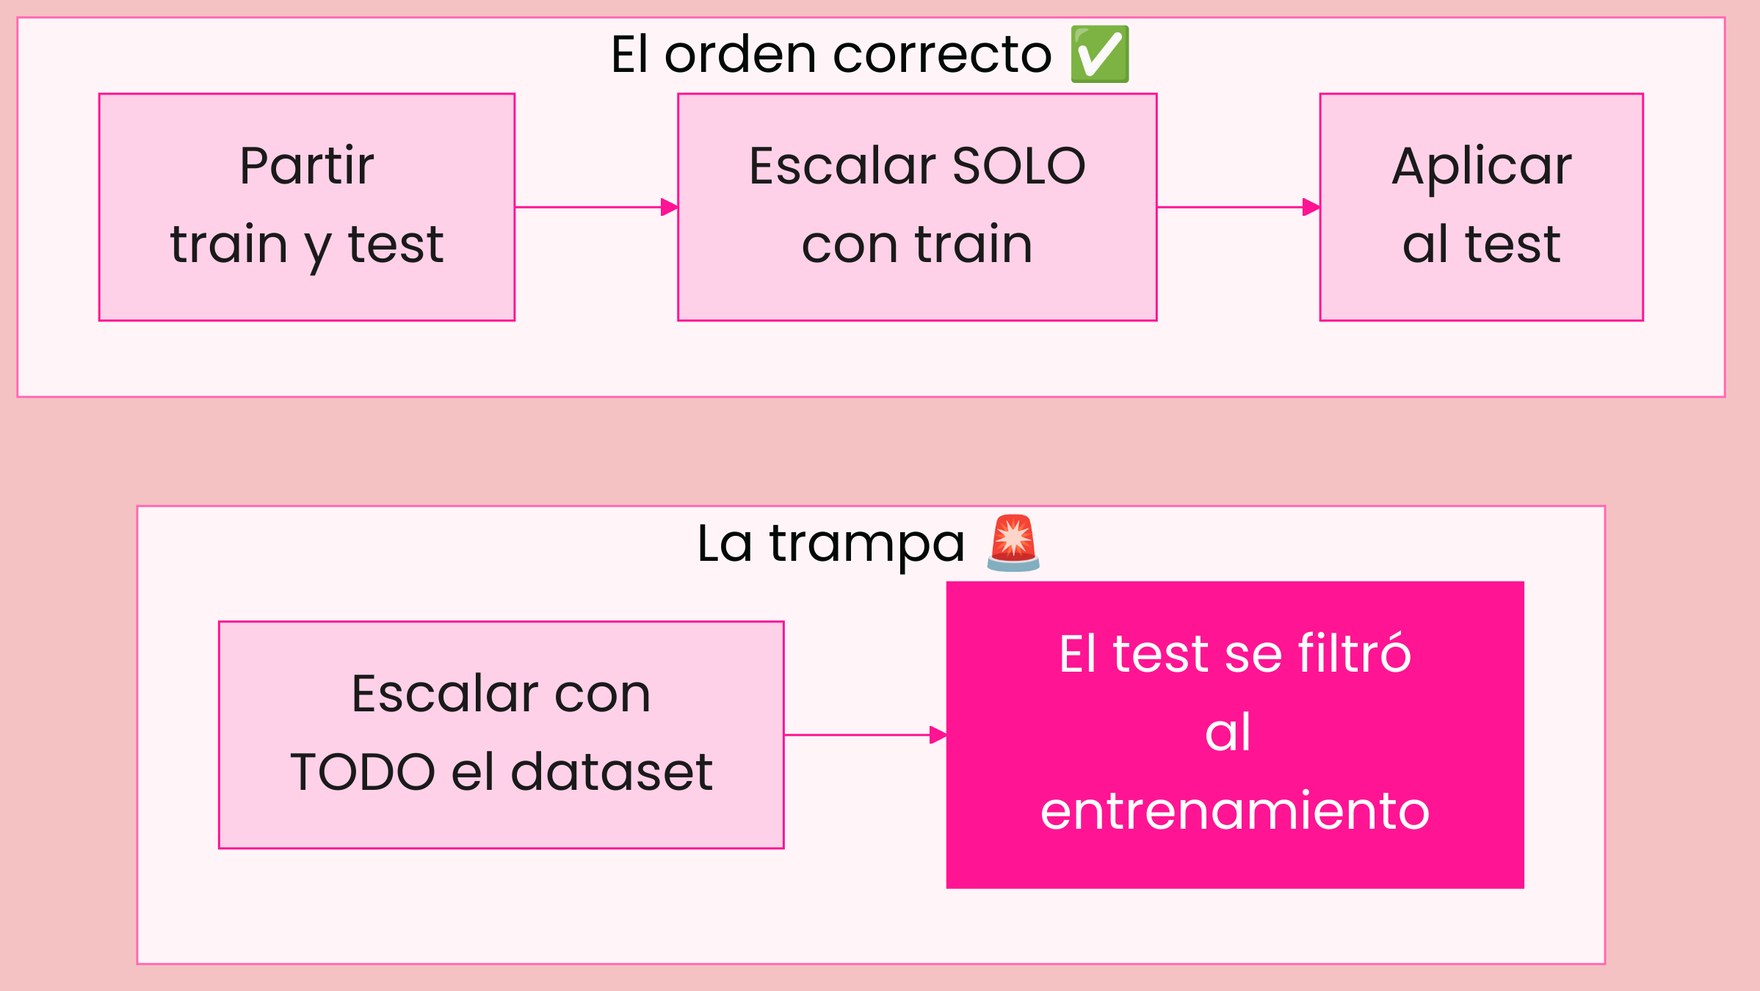

*El escalador se ajusta SOLO con train, si ve el test la evaluación queda contaminada.*


### 🧮 La matemática detrás · Estadística descriptiva, el z-score

$z = \dfrac{x - \mu}{\sigma}$

**Lectura en palabras,** a cada valor le resto el promedio y lo divido entre la desviación, ahora todas las variables hablan el mismo idioma.

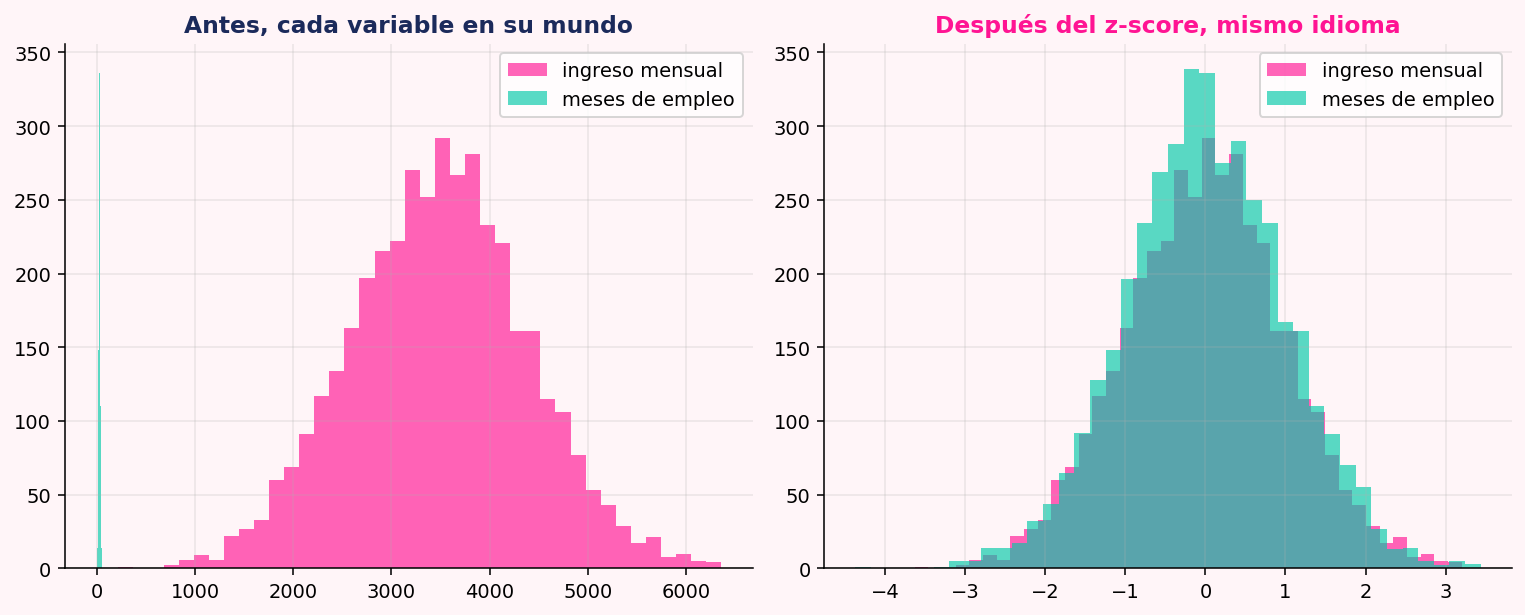

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;">🤔 <b>Por qué te sirve saberlo,</b> Media, desviación y distribución son el vocabulario mínimo de cualquier data scientist, sin ellas no puedes ni leer un boxplot.<br><br>🐥 No necesitas dominar esto hoy, necesitas saber que existe y a qué puerta tocar cuando quieras profundizar.</div>


In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
from sklearn.preprocessing import StandardScaler

numericas = ["edad", "ingreso_mensual", "monto_prestamo", "ratio_deuda_ingreso", "anios_empleo"]

escalador = ____()
# ✅ CORRECTO, el escalador aprende SOLO del train
X_train_esc = X_train.copy()
X_test_esc = X_test.copy()
X_train_esc[numericas] = escalador.____(X_train[numericas])
X_test_esc[numericas] = escalador.____(X_test[numericas])   # transform, sin fit

print("Promedios del train escalado (deben rondar cero),")
print(X_train_esc[numericas].mean().round(3))


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 La regla anti trampa más importante del curso</b><br>
fit_transform en train, solo transform en test. Si el escalador aprende del test, información del examen se filtra al estudio, eso es data leakage y produce métricas infladas que se desploman en producción. Grábatelo, el test no se toca ni para calcular un promedio.
</div>


## 8. 🏆 Reto para tu escuadrón, el checklist de preparación empaquetado

El reto pedía empaquetar todo el flujo en una función reutilizable que reciba data cruda y devuelva train y test listos. Solución verificada.

In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
# Solución del reto
def preparar_datos(df_crudo: pd.DataFrame, target: str = "impago"):
    """Pipeline completo de preparación, de data cruda a train y test listos."""
    d = df_crudo.copy()
    d = d.____(subset="cliente_id")
    d.loc[(d["edad"] < 18) | (d["edad"] > 100), "edad"] = np.nan
    d["distrito"] = d["distrito"].str.lower().str.strip()
    for col in ["edad", "ingreso_mensual", "meses_empleo"]:
        d[col] = d[col].fillna(d[col].median())
    d["ratio_deuda_ingreso"] = d["monto_prestamo"] / d["ingreso_mensual"]
    d = pd.____(d, columns=["distrito"], drop_first=True, dtype=int)
    feats = [c for c in d.columns if c not in ["cliente_id", target]]
    return ____(d[feats], d[target], test_size=____, random_state=42, stratify=d[target])


# La probamos desde cero con la data cruda regenerada
np.random.seed(42)
df_crudo = pd.DataFrame({
    "cliente_id": np.arange(500),
    "edad": np.random.randint(18, 70, 500).astype(float),
    "ingreso_mensual": np.round(np.random.lognormal(8.1, 0.5, 500), 0),
    "distrito": np.random.choice(["lima", "LIMA", "callao"], 500),
    "monto_prestamo": np.round(np.random.uniform(1000, 20000, 500), 0),
    "meses_empleo": np.random.randint(0, 240, 500).astype(float),
})
df_crudo["impago"] = (df_crudo["monto_prestamo"] / df_crudo["ingreso_mensual"] > 3.2).astype(int)

Xtr, Xte, ytr, yte = preparar_datos(df_crudo)
assert Xtr.isna().sum().sum() == 0 and Xte.isna().sum().sum() == 0
assert abs(ytr.mean() - yte.mean()) < 0.05
print(f"✅ Pipeline verificado, train {Xtr.shape} y test {Xte.shape} sin nulos y estratificados")

In [ ]:
#@title 🎬 Toca play · Comprueba tu reto antes del leaderboard
nombres_clave = ['df_crudo']
faltan = [x for x in nombres_clave if x not in globals()]
if faltan:
    print('🐥 Aún te falta definir,', ', '.join(faltan))
    print('   Revisa los espacios ✏️ TU TURNO de las celdas de arriba y vuelve a ejecutarlas.')
else:
    print('🎉 ¡Todas las piezas del reto existen, pollito!')
    print('   Compara tus números con el video de la clase 3 y anótate en el leaderboard con #PollitosML.')


<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 18px;">🎮 Trivia pollito, versión resuelta</b><br><br>
<b>1. ¿Qué porcentaje del trabajo real de ML es preparar datos?</b><ol type='a'><li>10%</li>
<li>✅ <b>Cerca del 80%</b></li>
<li>50%</li>
<li>Nada, lo hace la nube</li></ol><i>💡 La preparación domina el tiempo y define la calidad del resultado.</i><br>
<b>2. ¿Con qué imputamos una variable de cola larga como el ingreso?</b><ol type='a'><li>Con cero</li>
<li>✅ <b>Con la mediana</b></li>
<li>Con el máximo</li>
<li>Se borra la columna</li></ol><i>💡 La mediana resiste los valores extremos que engañan al promedio.</i><br>
<b>3. ¿Qué es data leakage?</b><ol type='a'><li>Perder el archivo</li>
<li>✅ <b>Que información del test se filtre al entrenamiento</b></li>
<li>Un tipo de gráfico</li>
<li>Datos duplicados</li></ol><i>💡 El escalador y las imputaciones se ajustan solo con el train.</i><br>
<b>4. ¿Para qué sirve stratify en el split?</b><ol type='a'><li>Para ordenar alfabéticamente</li>
<li>✅ <b>Para mantener la proporción de clases en train y test</b></li>
<li>Para acelerar</li>
<li>Para escalar</li></ol><i>💡 Ambas particiones quedan con el mismo balance del target.</i><br>
</div>



<div style="background: linear-gradient(135deg, #FF1493, #FF69B4); border-radius: 18px; padding: 28px 30px; color: white;">
<b style="font-size: 20px;">🏁 Recap de la clase</b>
<ul><li>Auditar primero, cada problema invisible se vuelve un modelo mentiroso</li>
<li>Limpiar con criterio, duplicados fuera, imposibles a nulo, mediana para colas largas</li>
<li>El feature engineering crea señal nueva, el ratio deuda ingreso valió oro</li>
<li>fit_transform en train y solo transform en test, la regla anti trampa</li></ul>
<b>📝 Tarea de la semana,</b> toma un dataset de Kaggle, ejecuta la auditoría completa, crea dos features nuevas y justifica cada decisión de limpieza en celdas de texto.<br><b>➡️ Próxima clase,</b> regresión con scikit-learn, predecimos números y entendemos qué mueve la aguja.
<br><br>
<div style="background: rgba(255,255,255,.16); border-radius: 12px; padding: 12px 18px; font-size: 14px;">
🐥 ¿Quieres seguir creciendo? En <b>missyera.com</b> encuentras mis cursos y consultoría de IA, y en <b>misscv.com</b> analizas tu CV gratis con inteligencia artificial.<br><br>
<b>Chau, chau. Bye, bye. 💋</b> · © 2026 Yera Flores · @soymissyera
</div>
</div>


## 🕵️ La trampa de la Miss

En la clase apareció una versión de este código que se ve inocente. Míralo bien, hay un error que en PolliCreditos costaría plata de verdad. ¿Lo encuentras?

```python
scaler = StandardScaler().fit(X)  # con TODO el dataset
X_train, X_test = train_test_split(scaler.transform(X))
```

<details style="background:#FFF5F8;border-radius:10px;padding:12px 16px;">
<summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">Toca aquí SOLO cuando tengas tu respuesta</summary>
<p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">El escalador se ajustó con TODO el dataset antes de partir, así que la media y la desviación ya vieron el test. Data leakage de manual, las métricas van a salir infladas. Primero se parte, después se escala solo con train.</p>
</details>

Cuéntame en los comentarios del video si la cazaste a la primera. 🐥


In [ ]:
#@title 🎬 Toca play · Quiz de salida, asegura lo de hoy
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de salida, asegura lo de hoy</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. Una solicitud con edad 220 años...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_0" value="0"> Se deja, puede ser verdad</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_0" value="1"> Es un valor imposible y se retira con su porqué documentado</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_0" value="2"> Se cambia por 22 sin avisar</label><div id="qout3_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Por qué el escalador se ajusta SOLO con train?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_1" value="0"> Para ahorrar memoria</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_1" value="1"> Porque si ve el test, la evaluación queda contaminada</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_1" value="2"> Porque el test no tiene números</label><div id="qout3_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">3. ¿Para qué sirve el encoding de la columna distrito?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_2" value="0"> Para ordenar los distritos</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_2" value="1"> Para convertir el texto en columnas numéricas que el modelo pueda usar</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout3_2" value="2"> Para eliminar los distritos raros</label><div id="qout3_2_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "limpiar con criterio es decidir y documentar"], [1, "es la trampa del data leakage"], [1, "los modelos solo comen n\u00fameros"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qout3_"+i+"\']:checked");
        var fb=document.getElementById("qout3_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🏟️ Tarjeta de leaderboard

Cuando completes el reto y la autoverificación te celebre, anota tu resultado y compártelo en los comentarios del video de la clase 3 con el hashtag #PollitosML. La solución oficial se publica en `soluciones/` una semana después del video.

| Equipo o pollito | Resultado del reto | ¿Qué probaste? |
|---|---|---|
| _tu nombre_ | _tu métrica_ | _tu jugada_ |


In [ ]:
#@title 🎬 Toca play · ¡Celebra lo que lograste hoy!
from IPython.display import HTML
import random
piezas = "".join(
    f'<div style="position:absolute;left:{random.randint(0,96)}%;top:-10%;font-size:{random.randint(16,30)}px;'
    f'animation:caer {random.uniform(2.4,4.2):.1f}s linear {random.uniform(0,1.6):.1f}s infinite;">'
    f'{random.choice(["🐥","🎉","💖","⭐","🎊"])}</div>' for _ in range(34))
HTML(f"""<div style="position:relative;height:230px;overflow:hidden;background:#FFF5F8;border-radius:16px;border:3px solid #E0218A;">
<style>@keyframes caer {{ to {{ transform: translateY(260px) rotate(360deg); }} }}</style>{piezas}
<div style="position:relative;text-align:center;padding-top:85px;">
<h2 style="color:#E0218A;margin:0;">¡Lo lograste, pollito! 🎓</h2>
<p style="color:#1B2A5B;">Completaste la clase. Respira, celebra y sigue.</p></div></div>""")

## 📖 El glosario que te llevas hoy

| Término | En palabras del curso |
|---|---|
| **Auditoría** | el interrogatorio inicial al dataset, tipos, nulos, duplicados, rangos sospechosos |
| **Feature engineering** | crear columnas nuevas con más señal a partir de las existentes |
| **Encoding** | convertir categorías de texto en números, porque los modelos solo comen números |
| **Train y test** | la partición sagrada, con una parte entrena y con la otra se examina |
| **Data leakage** | cuando información del test se filtra al entrenamiento y las métricas mienten |
| **Escalado** | llevar las variables a rangos comparables para los modelos que miden distancias |

Este glosario se acumula clase a clase, en el proyecto final te llevas el diccionario completo del curso.


## 🛤️ Tu ruta después de hoy

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><b style='color:#1B2A5B;'>Tu misión de la semana,</b> re-ejecuta este notebook de arriba a abajo prediciendo cada celda antes de correrla, y completa el reto de la versión estudiantes en el repositorio.</div>

En la clase 4 viene regresión, ¿qué línea de crédito darle a cada bodega?. Te espero en el siguiente video de la playlist.

El reto de esta clase vive en la carpeta `clases/` del repositorio del curso, y su solución se publica una semana después del video. Intenta primero, ahí está el aprendizaje.

Si quieres llevar esto al siguiente nivel, en [missyera.com](https://missyera.com) están el Full Day de IA y los cursos completos, y en [misscv.com](https://misscv.com) puedes analizar tu CV gratis con IA.

**Chau, chau. Bye, bye. 💋**

<sub>© 2026 Yera Flores (Miss Yera) · missyera.com · @soymissyera</sub>
